# Fase 2 & 3: Diagnostik, Feature Selection & Prediktif (Sistem Pendukung Keputusan)
Skrip ini mengeksekusi ekstraksi fitur (Phase 2), melatih model Machine Learning Hierarkis (Phase 3), serta memvisualisasikan SHAP XAI.

> **Kompatibilitas:** Skrip ini sudah dibuat **Universal** (bisa dijalankan langsung di **VS Code Laptop** maupun di **Databricks**).

In [5]:
%pip install matplotlib

     |████████████████████████████████| 7.8 MB 809 kB/s eta 0:00:01
     |████████████████████████████████| 64 kB 939 kB/s eta 0:00:01
     |████████████████████████████████| 2.9 MB 746 kB/s eta 0:00:01
     |████████████████████████████████| 249 kB 793 kB/s eta 0:00:01
     |████████████████████████████████| 4.7 MB 1.4 MB/s eta 0:00:01
     |████████████████████████████████| 122 kB 1.4 MB/s eta 0:00:01
You should consider upgrading via the '/Users/belvatalithadwiyanti/Documents/Projects/research/.venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [1]:
# 1. Inisialisasi & Import Library
import os
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import brier_score_loss, precision_recall_curve, auc
from scipy.stats import chi2_contingency, f_oneway
import shap
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# 2. Ingesti Data (Auto-Detect: Spark Table di Databricks ATAU CSV di VS Code)
df = pd.DataFrame()

# Jalur A: Coba baca dari Databricks Unity Catalog
try:
    if 'spark' in globals():
        df = spark.table("smt7_research.xauusd.xauusd_liquidity_gold").toPandas()
        print(f"[Mode Databricks] Berhasil memuat {len(df)} baris dari smt7_research.xauusd.xauusd_liquidity_gold")
except Exception:
    pass

# Jalur B: Coba baca dari CSV lokal jika berjalan di VS Code
if df.empty:
    local_paths = [
        "gold-data/gold-data.csv",
        "../gold-data/gold-data.csv",
        "/Users/belvatalithadwiyanti/Documents/Projects/research/gold-data/gold-data.csv"
    ]
    for p in local_paths:
        if os.path.exists(p):
            df = pd.read_csv(p)
            print(f"[Mode Lokal / VS Code] Berhasil membaca {len(df)} baris dari: {p}")
            break

if df.empty:
    raise FileNotFoundError("Gagal menemukan dataset Gold!")

# 3. Standarisasi Waktu & Penguncian OOS (2025-2026)
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)

cutoff_date = pd.to_datetime('2025-01-01', utc=True)
if df['timestamp'].dt.tz is None:
    cutoff_date = cutoff_date.tz_localize(None)

df_train_val = df[df['timestamp'] < cutoff_date].copy()
df_oos_final = df[df['timestamp'] >= cutoff_date].copy()

print(f"Rentang Waktu Keseluruhan : {df['timestamp'].min()} s/d {df['timestamp'].max()}")
print(f"Data Latih/Validasi (2016-2024): {len(df_train_val)} baris")
print(f"Data Ujian Akhir OOS (2025-2026): {len(df_oos_final)} baris")

/Users/belvatalithadwiyanti/Documents/Projects/research/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[Mode Lokal / VS Code] Berhasil membaca 3148 baris dari: ../gold-data/gold-data.csv
Rentang Waktu Keseluruhan : 2016-01-06 07:00:00+00:00 s/d 2026-07-31 13:00:00+00:00
Data Latih/Validasi (2016-2024): 2679 baris
Data Ujian Akhir OOS (2025-2026): 469 baris


## 2. Fase 2: Feature Engineering & Selection (Chi-Square & ANOVA)

In [3]:
# A. Feature Engineering
def create_features(data):
    d = data.copy()
    d['hour_of_day'] = d['timestamp'].dt.hour
    d['day_of_week'] = d['timestamp'].dt.dayofweek
    d['is_weekend_cross'] = (d['window_is_continuous'] == 0).astype(int)
    d['crossover_volume'] = d['volume']
    d['breakout_depth'] = np.where(
        d['level_type'].isin(['PDH', 'PWH']),
        d['high'] - d['level_price'],
        d['level_price'] - d['low']
    )
    return d

df_train_val = create_features(df_train_val)
df_oos_final = create_features(df_oos_final)

# B. Target M1 (1 = Pure Breakout, 0 = Sweep / Failed)
df_train_val['target_m1'] = (df_train_val['outcome'] == 'PURE_BREAKOUT').astype(int)

# C. Uji Statistik Chi-Square (Kategorikal)
print("=== HASIL UJI CHI-SQUARE (Kategorikal) ===")
cat_features = ['session', 'day_of_week', 'level_type', 'is_weekend_cross']
for col in cat_features:
    contingency = pd.crosstab(df_train_val[col], df_train_val['target_m1'])
    chi2, p, dof, ex = chi2_contingency(contingency)
    print(f"Fitur: {col:18} | p-value: {p:.5f} | Signifikan? {'YA (Lolos)' if p < 0.05 else 'TIDAK'}")

# D. Uji Statistik ANOVA (Numerikal)
print("\n=== HASIL UJI ANOVA (Numerikal) ===")
num_features = ['hour_of_day', 'crossover_volume', 'breakout_depth', 'window_hours']
for col in num_features:
    group1 = df_train_val[df_train_val['target_m1'] == 1][col].dropna()
    group0 = df_train_val[df_train_val['target_m1'] == 0][col].dropna()
    f_stat, p = f_oneway(group1, group0)
    print(f"Fitur: {col:18} | p-value: {p:.5f} | Signifikan? {'YA (Lolos)' if p < 0.05 else 'TIDAK'}")

selected_features = cat_features + num_features
for col in cat_features:
    df_train_val[col] = df_train_val[col].astype('category')
    if len(df_oos_final) > 0:
        df_oos_final[col] = df_oos_final[col].astype('category')

=== HASIL UJI CHI-SQUARE (Kategorikal) ===
Fitur: session            | p-value: 0.00254 | Signifikan? YA (Lolos)
Fitur: day_of_week        | p-value: 0.39627 | Signifikan? TIDAK
Fitur: level_type         | p-value: 0.00002 | Signifikan? YA (Lolos)
Fitur: is_weekend_cross   | p-value: 1.00000 | Signifikan? TIDAK

=== HASIL UJI ANOVA (Numerikal) ===
Fitur: hour_of_day        | p-value: 0.28241 | Signifikan? TIDAK
Fitur: crossover_volume   | p-value: 0.02245 | Signifikan? YA (Lolos)
Fitur: breakout_depth     | p-value: 0.00000 | Signifikan? YA (Lolos)
Fitur: window_hours       | p-value: 0.86592 | Signifikan? TIDAK


## 3. Fase 3: Purged Walk-Forward CV & Model Training

In [4]:
X_train = df_train_val[selected_features]
y_train = df_train_val['target_m1']

# Protokol Purged Walk-Forward (Embargo 6 Candle)
class PurgedWalkForwardCV:
    def __init__(self, n_splits=6, embargo_rows=6):
        self.n_splits = n_splits
        self.embargo_rows = embargo_rows
        
    def split(self, X, y=None, groups=None):
        tscv = TimeSeriesSplit(n_splits=self.n_splits)
        for train_idx, test_idx in tscv.split(X):
            if len(train_idx) > self.embargo_rows:
                purged_train_idx = train_idx[:-self.embargo_rows]
            else:
                purged_train_idx = train_idx
            yield purged_train_idx, test_idx
            
    def get_n_splits(self, X=None, y=None, groups=None):
        return self.n_splits

cv = PurgedWalkForwardCV(n_splits=5, embargo_rows=6)

print("--- Melatih Model LightGBM Terkalibrasi ---")
base_lgb = lgb.LGBMClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=5,
    class_weight='balanced',
    verbose=-1,
    random_state=42
)

calibrated_lgb = CalibratedClassifierCV(estimator=base_lgb, method='isotonic', cv=cv)
calibrated_lgb.fit(X_train, y_train)
print("Pelatihan Selesai! Menguji model pada data OOS terkunci (2025-2026)...\n")

# Evaluasi pada OOS (Ujian Kelulusan Akhir)
if len(df_oos_final) > 0:
    X_oos = df_oos_final[selected_features]
    y_oos = (df_oos_final['outcome'] == 'PURE_BREAKOUT').astype(int)
    
    y_prob_oos = calibrated_lgb.predict_proba(X_oos)[:, 1]
    
    brier = brier_score_loss(y_oos, y_prob_oos)
    precision, recall, _ = precision_recall_curve(y_oos, y_prob_oos)
    pr_auc = auc(recall, precision)
    
    print("====== HASIL EVALUASI OOS FINAL (2025 - 2026) ======")
    print(f"Total Data Uji (N)                  : {len(X_oos)} Event")
    print(f"Brier Score (Mendekati 0 makin baik): {brier:.4f}")
    print(f"PR-AUC (Mendekati 1 makin baik)     : {pr_auc:.4f}")
    print("====================================================\n")
    
    # Logika Sistem Pendukung Keputusan (DSS)
    print("=== SIMULASI DSS (Abstain Zone 35% - 65%) ===")
    df_oos_final['P_Breakout'] = y_prob_oos
    
    conditions = [
        (df_oos_final['P_Breakout'] >= 0.65),
        (df_oos_final['P_Breakout'] <= 0.35)
    ]
    choices = ['SIGNAL_BREAKOUT (Follow)', 'SIGNAL_SWEEP (Fade/Reversal)']
    df_oos_final['DSS_Rekomendasi'] = np.select(conditions, choices, default='ZONA_ABSTAIN (No Trade)')
    
    distribusi = df_oos_final['DSS_Rekomendasi'].value_counts().to_frame("Jumlah Keputusan")
    print(distribusi)

--- Melatih Model LightGBM Terkalibrasi ---
Pelatihan Selesai! Menguji model pada data OOS terkunci (2025-2026)...

====== HASIL EVALUASI OOS FINAL (2025 - 2026) ======
Total Data Uji (N)                  : 469 Event
Brier Score (Mendekati 0 makin baik): 0.2087
PR-AUC (Mendekati 1 makin baik)     : 0.5417

=== SIMULASI DSS (Abstain Zone 35% - 65%) ===
                              Jumlah Keputusan
DSS_Rekomendasi                               
ZONA_ABSTAIN (No Trade)                    197
SIGNAL_SWEEP (Fade/Reversal)               193
SIGNAL_BREAKOUT (Follow)                    79


## 4. Interpretabilitas Model via SHAP (XAI)

Menghitung nilai kontribusi fitur (SHAP Values)...


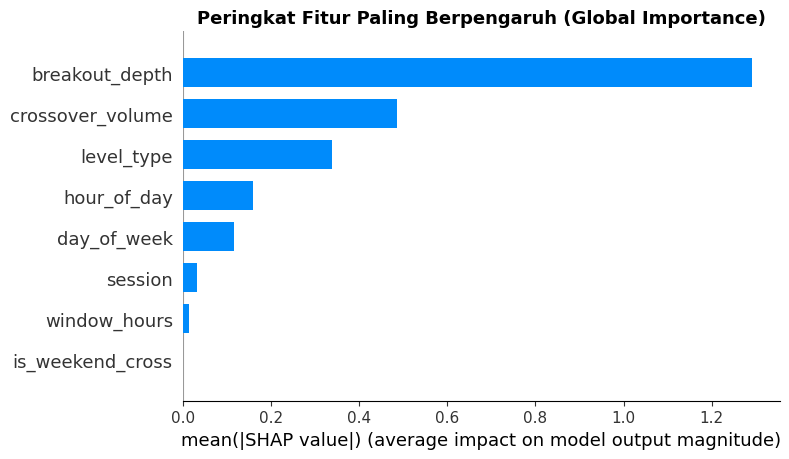

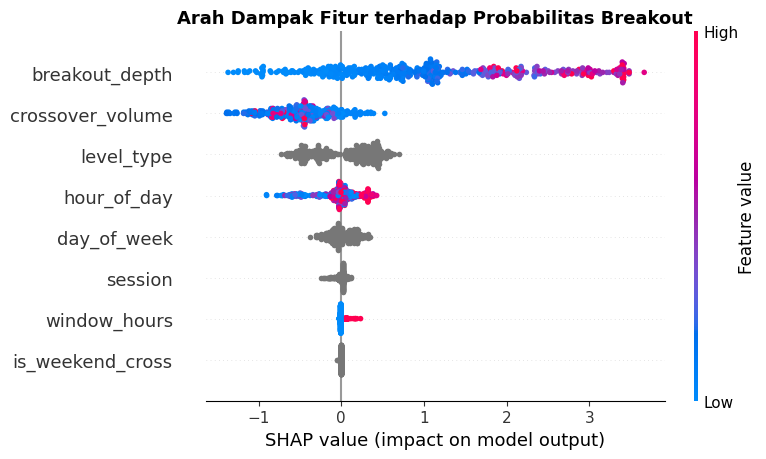

In [5]:
print("Menghitung nilai kontribusi fitur (SHAP Values)...")
base_lgb.fit(X_train, y_train)
explainer = shap.TreeExplainer(base_lgb)
shap_values = explainer.shap_values(X_oos)

if isinstance(shap_values, list):
    shap_values_to_plot = shap_values[1]
else:
    shap_values_to_plot = shap_values

# Plot 1: Bar Plot Feature Importance
plt.figure(figsize=(10, 5))
shap.summary_plot(shap_values_to_plot, X_oos, plot_type="bar", show=False)
plt.title("Peringkat Fitur Paling Berpengaruh (Global Importance)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Plot 2: Beeswarm Plot
plt.figure(figsize=(10, 5))
shap.summary_plot(shap_values_to_plot, X_oos, show=False)
plt.title("Arah Dampak Fitur terhadap Probabilitas Breakout", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()